# ERA V5 · Session 12 — ZeRO 1/2/3 on 32 virtual GPUs

- 32 ranks simulated in one process; collectives written by hand so every byte sent is counted.
- Mixed-precision state per weight: bf16 weight (2) + bf16 grad (2) + fp32 master (4) + Adam m, v (8) = 16 bytes.
- Runs DP, ZeRO-1, ZeRO-2, ZeRO-3 on the same data; measures memory per GPU, communication per step, compute.
- Needs only `torch` + `matplotlib` (Colab default). Uses the Colab GPU if enabled, else CPU.

In [1]:
import time, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

N = 32                 # world size: 32 virtual GPUs (ranks 0..31)
L, D = 8, 256          # layers, width
B = 4                  # samples per GPU per step -> global batch 128
STEPS = 10
LR, B1, B2, EPS = 1e-3, 0.9, 0.999, 1e-8

NUMEL = D * D + D      # flat params per layer = 65,792 = 32 x 2,056
assert NUMEL % N == 0
PARAMS = L * NUMEL
P_BYTES = PARAMS * 2   # P = one bf16 copy of the model
BF16 = torch.bfloat16
DEV = "cuda" if torch.cuda.is_available() else "cpu"
def sync():
    if DEV == "cuda": torch.cuda.synchronize()   # honest timing on GPU

teacher = torch.randn(D, D, device=DEV) / D**0.5
X = torch.randn(STEPS, N, B, D, device=DEV)
Y = torch.tanh(X @ teacher)
init = [torch.cat([torch.randn(D * D, device=DEV) / D**0.5, torch.zeros(D, device=DEV)]) for _ in range(L)]
print(f"device={DEV}  params={PARAMS:,}  P={P_BYTES/1e6:.2f} MB  global batch={N*B}")

device=cpu  params=526,336  P=1.05 MB  global batch=128


## Memory tracker + collectives
- `Mem`: bytes live on one GPU (training state + transient buffers; activations excluded, same for all stages).
- Ring cost per rank: reduce-scatter and all-gather each send `(N-1)/N` of the tensor. All-reduce = both.

In [2]:
class Mem:
    def __init__(self): self.live, self.cur, self.peak = {}, 0, 0
    def alloc(self, name, t):
        self.free(name)
        self.live[name] = t.numel() * t.element_size()
        self.cur += self.live[name]
        self.peak = max(self.peak, self.cur)
    def free(self, name):
        self.cur -= self.live.pop(name, 0)

comm = {"bytes": 0}   # bytes SENT by one rank (all ranks symmetric in a ring)

def reduce_scatter(fulls):
    """N full tensors (one per rank) -> N shards; rank r gets the SUM of shard r."""
    total = torch.zeros(fulls[0].numel(), device=fulls[0].device)
    for t in fulls:                       # fixed order -> deterministic
        total += t.float()
    comm["bytes"] += (N - 1) / N * fulls[0].numel() * 2
    return list(total.chunk(N))

def all_gather(shards):
    """N shards (one per rank) -> the full tensor every rank now holds."""
    full = torch.cat(shards)
    comm["bytes"] += (N - 1) / N * full.numel() * 2
    return full

## Model (L linear layers, flat params per layer) + Adam

In [3]:
def layer(p, x, last):
    W, b = p[: D * D].view(D, D), p[D * D :]
    y = x @ W.T + b
    return y if last else F.gelu(y)

def adam(master, m, v, g, t):          # elementwise -> sharding does not change the result
    m.mul_(B1).add_(g, alpha=1 - B1)
    v.mul_(B2).addcmul_(g, g, value=1 - B2)
    mh, vh = m / (1 - B1**t), v / (1 - B2**t)
    master.sub_(LR * mh / (vh.sqrt() + EPS))

## One training run for a given stage
| stage | weights | grads | master + m + v | comm |
|---|---|---|---|---|
| DP | full | full | full | RS + AG of grads = 2P |
| Z1 | full | full | shard | RS grads + AG weights = 2P |
| Z2 | full | shard | shard | same = 2P |
| Z3 | shard | shard | shard | AG fwd + AG bwd + RS = 3P |

In [4]:
def run(stage):
    comm["bytes"] = 0
    mem = [Mem() for _ in range(N)]
    S = [dict() for _ in range(N)]        # S[r][(name, layer)] = tensor on rank r

    # ---- persistent state ----
    for r in range(N):
        for l in range(L):
            shard = init[l].chunk(N)[r]
            own = init[l] if stage == "DP" else shard                       # optimizer-state scope
            S[r]["master", l] = own.clone()                                  # fp32 copy (4 B)
            S[r]["m", l] = torch.zeros_like(own)                             # Adam m    (4 B)
            S[r]["v", l] = torch.zeros_like(own)                             # Adam v    (4 B)
            S[r]["w", l] = (shard if stage == "Z3" else init[l]).to(BF16)   # bf16 w    (2 B)
            for k in ("master", "m", "v", "w"):
                mem[r].alloc((k, l), S[r][k, l])

    def weights(l):
        """Full bf16 weights of layer l per rank. Z3 has to gather them first."""
        if stage != "Z3":
            return [S[r]["w", l] for r in range(N)]
        full = all_gather([S[q]["w", l] for q in range(N)])
        for r in range(N): mem[r].alloc("gathered", full)
        return [full] * N

    def drop_gathered():
        if stage == "Z3":
            for r in range(N): mem[r].free("gathered")

    losses, t_fb, t_opt = [], 0.0, 0.0
    for step in range(STEPS):
        sync(); t0 = time.time()
        # ---- forward ----
        acts = [[X[step, r]] for r in range(N)]
        for l in range(L):
            ws = weights(l)
            for r in range(N):
                acts[r].append(layer(ws[r].float(), acts[r][-1], l == L - 1))
            drop_gathered()

        # ---- loss ----
        gy, step_loss = [], 0.0
        for r in range(N):
            out = acts[r][-1].detach().requires_grad_()
            loss = F.mse_loss(out, Y[step, r])
            gy.append(torch.autograd.grad(loss, out)[0])
            step_loss += loss.item() / N
        losses.append(step_loss)

        # ---- backward: one layer = one bucket ----
        for l in reversed(range(L)):
            ws = weights(l)                                   # Z3: gather again
            grads = []
            for r in range(N):
                p = ws[r].float().requires_grad_()
                x = acts[r][l].detach().requires_grad_()
                gp, gy[r] = torch.autograd.grad(layer(p, x, l == L - 1), (p, x), gy[r])
                grads.append(gp.to(BF16))
                mem[r].alloc(("grad", l), grads[-1])         # full grad (2 B)
            drop_gathered()

            shards = reduce_scatter(grads)                    # rank r keeps summed shard r
            for r in range(N):
                S[r]["gsh", l] = (shards[r] / N).to(BF16)    # averaged grad shard
                if stage in ("Z2", "Z3"):                     # full grad not needed any more
                    mem[r].free(("grad", l))
                    mem[r].alloc(("gsh", l), S[r]["gsh", l])
            if stage == "DP":                                 # all-reduce = RS + AG
                avg = all_gather([S[q]["gsh", l] for q in range(N)])
                for r in range(N): S[r]["gfull", l] = avg
        sync(); t_fb += time.time() - t0

        # ---- optimizer: DP updates everything on every rank, ZeRO only its shard ----
        sync(); t0 = time.time()
        for r in range(N):
            for l in range(L):
                g = S[r]["gfull" if stage == "DP" else "gsh", l].float()
                adam(S[r]["master", l], S[r]["m", l], S[r]["v", l], g, step + 1)
        sync(); t_opt += time.time() - t0

        # ---- refresh bf16 weights ----
        for l in range(L):
            if stage in ("Z1", "Z2"):                         # share updated shards back out
                full = all_gather([S[q]["master", l].to(BF16) for q in range(N)])
                for r in range(N): S[r]["w", l] = full
            else:                                             # DP: own full copy, Z3: own shard
                for r in range(N): S[r]["w", l] = S[r]["master", l].to(BF16)

        for r in range(N):                                    # zero_grad(set_to_none=True)
            for l in range(L):
                mem[r].free(("grad", l)); mem[r].free(("gsh", l))

    master = [S[0]["master", l] if stage == "DP"
              else torch.cat([S[r]["master", l] for r in range(N)]) for l in range(L)]
    return dict(loss=losses, master=torch.cat(master),
                peak=max(m.peak for m in mem) / PARAMS,
                commP=comm["bytes"] / STEPS / P_BYTES,
                t_fb=t_fb / STEPS, t_opt=t_opt / STEPS / N)

## Run all four stages

In [5]:
def theory(stage, n):
    return {"DP": 16, "Z1": 4 + 12 / n, "Z2": 2 + 14 / n, "Z3": 16 / n}[stage]

results = {s: run(s) for s in ("DP", "Z1", "Z2", "Z3")}
names = list(results)

print(f"{'stage':6}{'theory B/p':>11}{'peak B/p':>10}{'comm/step':>11}{'fwd+bwd s':>11}{'opt/rank':>11}")
for s, r in results.items():
    print(f"{s:6}{theory(s, N):11.3f}{r['peak']:10.3f}{r['commP']:10.3f}P"
          f"{r['t_fb']:11.3f}{r['t_opt']*1e3:9.3f}ms")

stage  theory B/p  peak B/p  comm/step  fwd+bwd s   opt/rank
DP         16.000    16.000     1.938P      0.678    2.772ms
Z1          4.375     4.375     1.938P      0.187    0.634ms
Z2          2.438     2.680     1.938P      0.255    0.899ms
Z3          0.500     0.992     2.906P      0.282    0.999ms


**Read the table**
1. Theory = the 16-byte table from the lecture. Peak = measured, incl. transient buffers.
2. Z2 peak > theory: one layer's full grad lives until its reduce-scatter.
3. Z3 peak > theory: one gathered layer + its full grad live briefly.
4. Comm = 2(N-1)/N ≈ 1.94P for DP/Z1/Z2, 3(N-1)/N ≈ 2.91P for Z3.
5. fwd+bwd compute is the same work for all stages; optimizer work per rank drops 32x under ZeRO.

## Correctness checks

In [6]:
base = results["DP"]["master"]
for s in ("Z1", "Z2", "Z3"):
    print(s, "weights bit-identical to DP after", STEPS, "steps:", torch.equal(base, results[s]["master"]))

# DP: avg of 32 grads (4 samples each) == one GPU on all 128 samples (fp32, last layer, step 0)
p = init[-1].clone().requires_grad_()
h = X[0]
for l in range(L - 1): h = layer(init[l], h, False)
big = torch.autograd.grad(F.mse_loss(layer(p, h.reshape(-1, D), True), Y[0].reshape(-1, D)), p)[0]
small = sum(torch.autograd.grad(F.mse_loss(layer(p, h[r], True), Y[0, r]), p)[0] for r in range(N)) / N
print("max |avg of 32 grads - 128-batch grad| =", (big - small).abs().max().item())

Z1 weights bit-identical to DP after 10 steps: True
Z2 weights bit-identical to DP after 10 steps: True
Z3 weights bit-identical to DP after 10 steps: True
max |avg of 32 grads - 128-batch grad| = 3.4924596548080444e-10


## Plots

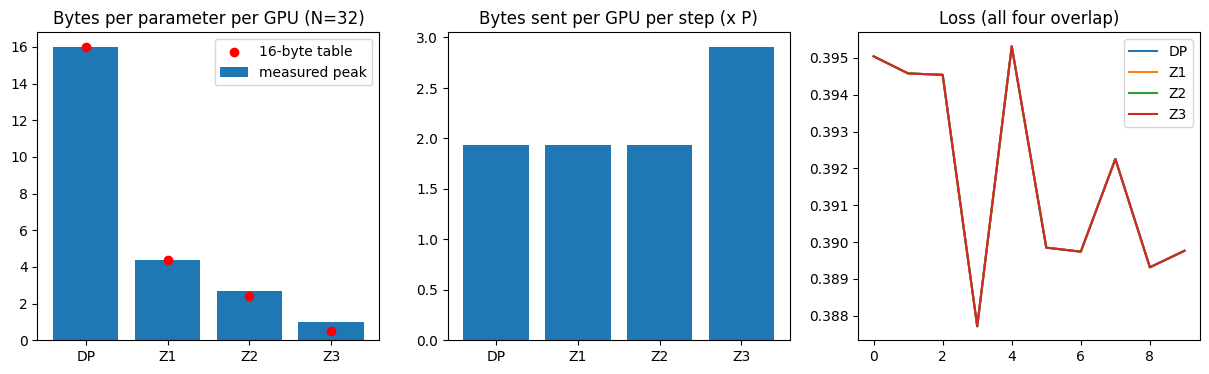

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(names, [results[s]["peak"] for s in names], label="measured peak")
ax[0].scatter(names, [theory(s, N) for s in names], color="red", zorder=3, label="16-byte table")
ax[0].set_title("Bytes per parameter per GPU (N=32)"); ax[0].legend()
ax[1].bar(names, [results[s]["commP"] for s in names])
ax[1].set_title("Bytes sent per GPU per step (x P)")
for s in names: ax[2].plot(results[s]["loss"], label=s)
ax[2].set_title("Loss (all four overlap)"); ax[2].legend()
plt.show()

## Scale to V5: 30B params, 80 GB (74.5 GiB) cards

In [8]:
GiB, CARD, W, P30 = 2**30, 74.5, 30e9, 60e9
print(f"{'GiB/GPU':8}" + "".join(f"{n:>9}" for n in (8, 16, 32, 64)))
for s in names:
    cells = [theory(s, n) * W / GiB for n in (8, 16, 32, 64)]
    print(f"{s:8}" + "".join(f"{c:8.1f}{'*' if c <= CARD else ' '}" for c in cells))
print("* fits\n")
for s in names:
    k = 3 if s == "Z3" else 2
    print(f"{s}: {k}P = {k*P30/1e9:.0f} GB/step -> NVLink {k*P30/450e9:.2f}s | InfiniBand {k*P30/50e9:.2f}s")

GiB/GPU         8       16       32       64
DP         447.0    447.0    447.0    447.0 
Z1         153.7    132.7    122.2    117.0 
Z2         104.8     80.3     68.1*    62.0*
Z3          55.9*    27.9*    14.0*     7.0*
* fits

DP: 2P = 120 GB/step -> NVLink 0.27s | InfiniBand 2.40s
Z1: 2P = 120 GB/step -> NVLink 0.27s | InfiniBand 2.40s
Z2: 2P = 120 GB/step -> NVLink 0.27s | InfiniBand 2.40s
Z3: 3P = 180 GB/step -> NVLink 0.40s | InfiniBand 3.60s
